用模拟退火算法求解30个城市的TSP问题 

In [1]:
import numpy as np
import time
import random
import matplotlib.pyplot as plt
import re

plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 使用微软雅黑
plt.rcParams["axes.unicode_minus"] = False         # 解决负号显示问题

数据预处理 \
城市数据存储在'30城市.txt'中，每个城市给出x坐标，y坐标，并以';'分隔城市。\
为了方便后续处理，将数据读入python中，并转化为城市邻接矩阵，以距离作为权重

In [2]:
def load_data(file_path):
    """
    从txt文件中读取以分号分隔的城市x, y坐标, 返回城市坐标列表

    :param file_path: txt文件路径
    :return city_coords: 城市坐标列表 [(x1, y1), (x2, y2), ...]
    """
    with open(file_path, 'r') as f:
        data = f.read()

    data = data.replace('\n', '')     # 去除换行符 将txt文件按一个字符串读出
    data = data.split(';')            # 分号分隔每个城市坐标

    city_coords = []
    for city in data:                
        x = city.split(' ')[0]   
        y = city.split(' ')[1]
        city_coords.append((float(x), float(y)))
    
    return city_coords

In [3]:
def load_data_re(file_path):
    """
    用正则表达式
    从txt文件中读取以分号分隔的城市x, y坐标, 返回城市坐标列表

    :param file_path: txt文件路径
    :return city_coords: 城市坐标列表 [(x1, y1), (x2, y2), ...]
    """
    with open(file_path, 'r') as f:
        data = f.read()

    pattern = re.compile(r'(\d+)\s+(\d+)')   # x y
    matches = pattern.findall(data)

    city_coords = []
    for city in matches:                
        x = city[0]   
        y = city[1]
        city_coords.append((float(x), float(y)))
    
    return city_coords

In [4]:
# file_path = '30城市.txt'
# city_coords = load_data(file_path)
file_path = '30城市正则test.txt'
city_coords = load_data_re(file_path)
print(f'总共有{len(city_coords)}个城市')
print('城市坐标列表：')
print(city_coords)

总共有30个城市
城市坐标列表：
[(41.0, 94.0), (37.0, 84.0), (54.0, 67.0), (25.0, 62.0), (7.0, 64.0), (2.0, 99.0), (68.0, 58.0), (71.0, 44.0), (54.0, 62.0), (83.0, 69.0), (64.0, 60.0), (18.0, 54.0), (22.0, 60.0), (83.0, 46.0), (91.0, 38.0), (25.0, 38.0), (24.0, 42.0), (58.0, 69.0), (71.0, 71.0), (74.0, 78.0), (87.0, 76.0), (18.0, 40.0), (13.0, 40.0), (82.0, 7.0), (62.0, 32.0), (58.0, 35.0), (45.0, 21.0), (41.0, 26.0), (44.0, 35.0), (4.0, 50.0)]


In [5]:
def cal_dist_matrix(city_coords):
    """ 
    根据城市坐标, 计算并返回以距离为权重的邻接矩阵

    :param city_coords: 城市坐标列表 [(x1, y1), (x2, y2), ...]
    :return dist_matrix: 距离邻接矩阵
    """
    n = len(city_coords)                       # 城市数量
    dist_matrix = np.zeros((n, n))             # 初始化距离矩阵
    for i in range(n):                         # 对每个城市
        x1, y1 = city_coords[i]
        for j in range(n):                     # 计算与其他城市的距离
            if i != j:
                x2, y2 = city_coords[j]
                dist_matrix[i][j] = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
    return dist_matrix

dist_matrix = cal_dist_matrix(city_coords)
print('城市距离邻接矩阵：')
print(dist_matrix)

城市距离邻接矩阵：
[[  0.          10.77032961  29.96664813  35.77708764  45.3431362
   39.3192065   45.          58.30951895  34.53983208  48.87739764
   41.0487515   46.14108798  38.94868419  63.78087488  75.07329752
   58.24087911  54.70831747  30.23243292  37.80211634  36.67424164
   49.39635614  58.69412236  60.8276253   96.17692031  65.4599114
   61.40032573  73.10950691  68.          59.07622195  57.48912941]
 [ 10.77032961   0.          24.04163056  25.05992817  36.05551275
   38.07886553  40.45985665  52.49761899  27.80287755  48.38388161
   36.12478374  35.51056181  28.3019434   59.66573556  70.9365914
   47.5394573   43.96589587  25.8069758   36.40054945  37.48332963
   50.6359556   47.92702787  50.11985634  89.18520057  57.69748695
   53.31041174  63.50590524  58.13776741  49.49747468  47.38143096]
 [ 29.96664813  24.04163056   0.          29.42787794  47.09564736
   61.05735009  16.64331698  28.60069929   5.          29.06888371
   12.20655562  38.27531842  32.75667871  35.80502758

模拟退火求解TSP

先实现传统的模拟退火

In [6]:
# 需要的函数      
def cal_distance(dist_matrix, path):
    """
    计算TSP可行路径的总距离
    
    :param dist_matrix: 城市邻接矩阵
    :param path: 可行路径
    :return distance: 路径总距离
    """
    distance = 0
    for i in range(len(dist_matrix)):
        distance += dist_matrix[path[i]][path[i+1]]
    return distance

def plot_tsp_path(city_coords, path, title='TSP路径'):
    """
    可视化TSP路径
    
    :param city_coords: 城市坐标列表，每个元素为(x, y)元组
    :param path: 路径列表，包含城市索引（如[0, 3, 1, ..., 0]表示闭环路径）
    :param title: 绘图的标题
    """
    # 提取路径中所有城市的坐标
    x = [city_coords[i][0] for i in path]
    y = [city_coords[i][1] for i in path]
    
    # 创建画布
    plt.figure(figsize=(10, 6))
    
    # 绘制路径（连接线）
    plt.plot(x, y, 'b-', linewidth=1.5, alpha=0.7, label='路径')
    
    # 绘制城市点（普通城市）
    plt.scatter(x, y, c='skyblue', s=80, edgecolors='black', linewidths=0.8, label='城市')
    
    
    # 添加标签和标题
    plt.title(title, fontsize=14)
    plt.xlabel('X坐标', fontsize=12)
    plt.ylabel('Y坐标', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # 显示图表
    plt.show()

def plot_distance_record(distance_record, title='每轮迭代的路径距离'):
    """ 
    可视化每轮迭代的路径距离

    :param distance_record: list, 记录每轮迭代的路径距离
    :param title: 绘图的标题
    """
    plt.figure(figsize=(10, 6))
    
    plt.plot(distance_record)

    plt.title(title)
    plt.xlabel('epoch')
    plt.ylabel('路径距离')
    plt.show()

TSP问题，所求的路径是一条恰好访问每座城市一次，并回到起始城市的最短回路。\
回路意味着路径的起始城市可以是任意的 \
首先，为了方便起见，将起始城市选定为0，并将路径初始化为0, 1, ..., 29, 0 \
注意，这里将代码里的路径定义为起始城市，途径城市(...), 起始城市(返回终点) \
接下来构造新解时，起始城市可以不用变动，只需变动途径城市即可构造出一条新路径 \
所以代码中也是按照这一思路实现 

构造新解使用了三种方法:
1. 随机交换两个城市位置 
2. 将路径切分为两条子路径, 其中一条翻转后再次拼接, 生成新路径 
3. 随机选取某个城市，并随机插入到另一位置

In [7]:
# 构造新解的方法
def change_two_cities(path):
    """  
    随机交换两个城市位置生成新路径

    :param path: 可行路径
    :return new_path: 新可行路径
    """
    new_path = path.copy()                           # 复制，不修改原路径
    i, j = random.sample(range(1, len(path)-1), 2)   # 从列表中随机抽取不重复元素, path头尾固定为城市0，不用交换
    new_path[i], new_path[j] = new_path[j], new_path[i]
    return new_path

def reverse_subpath(path):
    """
    将路径切分为两条子路径, 其中一条翻转后再次拼接, 生成新路径
    
    :param path: 可行路径
    :return new_path: 新可行路径
    """
    i, j = random.sample(range(1, len(path)-1), 2)   # [1, 29] 随机抽取不重复元素
    if i > j:         
        i, j = j, i  # 同时交换

    new_path = path.copy()
    subpath = new_path[i:j+1]
    new_path = new_path[:i] + subpath[::-1] + new_path[j+1:]     
    return new_path

def select_insert_one_city(path):
    """ 
    随机选取某个城市, 并将其插入到另一位置

    :param path: 可行路径
    :return new_path: 新可行路径
    """
    i, j = random.sample(range(1, len(path)-1), 2)   # [1, 29] 随机抽取不重复元素

    new_path = path.copy()
    city = new_path.pop(i)
    new_path.insert(j, city)
    return new_path

模拟退火算法 \
外层循环，控制降温的过程，即控制迭代多少次 \
内层循环，是当前温度下的采样过程，要控制循环的次数，即生成新可行解的数量L 

内层循环不断挖出新解，总是接受更好的解，一定概率接受更差的解 \
而外层循环通过控制温度，温度高时，更高概率接受差解，温度低时，几乎不可能接受差解，从而促使算法收敛到最优值

对于内层循环，主要是通过三种方式构造新解 \
不断更新当前解，并记录最优解

In [8]:
# 实现内层循环
# 对于同名变量，函数内部默认优先使用局部变量
def SA_TSP_sampling(L, t, dist_matrix, cur_path):
    """ 
    SA算法内层循环的采样过程

    :param L: 采样次数
    :param t: 当前温度
    :param dist_matrix: 邻接距离矩阵
    :param cur_path: 当前解的路径(输入算法, 作为起始)
    :return cur_path: 当前解的路径(算法结束时)
    :return best_path: 最优解的路径
    """
    cur_distance = cal_distance(dist_matrix, cur_path)    # 当前解的路径距离
    best_path = cur_path                                  # 初始化最优解的路径
    best_distance = cur_distance                          # 初始化最优解的路径距离

    for _ in range(L):      # 进行L次采样获取新解
        # 根据当前路径，用三种方法构造新路径
        p  = random.random()                              # 生成一个01之间的随机小数
        if p <= 1/3:                        
            new_path = change_two_cities(cur_path)
        elif p > 1/3 and p <= 2/3:
            new_path = reverse_subpath(cur_path)
        else: 
            new_path = select_insert_one_city(cur_path)
            
        new_distance = cal_distance(dist_matrix, new_path)

        delta = new_distance - cur_distance               # 新可行解和当前可行解之间的路径距离之差
        if delta < 0:                                     # 当新解更优时，直接把新解作为当前解
            cur_path = new_path
            cur_distance = new_distance
            if cur_distance < best_distance:              # 更新最优解
                best_path = cur_path 
                best_distance = cur_distance
        else:                                             # 当新解更差时，仍有一定概率将新解作为当前解
            if random.random() < np.exp(-delta/t):        # 新解越差，接受概率越小；温度越高，接受概率越大
                cur_path = new_path
                cur_distance = new_distance
    return (cur_path, best_path)

对于外部循环，当前解是一直保持更新的，即当前解只有一个，每次传入内部循环再接收回来，不断牵出新解 \
而外部循环的最优解，只有当这一轮的内部循环最优解比外部循环最优解还优时，才更新 \
实现功能有：\
外部循环，对每50轮温度下的当前解的路径实现可视化 \
记录每轮当前解、最优解的路径距离，在算法结束后，可以画出，这样观察每轮的路径距离变化，理解算法的运行 

In [9]:
def SA_TSP(city_coords, dist_matrix, T0=100, T_end=0.01, K=0.99, L=100, verbose=0):
    """ 
    模拟退火算法解决TSP问题

    :param city_coords: 城市坐标列表
    :param dist_matrix: 城市邻接距离矩阵
    :param T0: 初始温度, 默认值100
    :param T_end: 最终温度, 默认值0.01
    :param K: 温度衰减系数, 默认值0.99
    :param L: 每轮温度，生成新可行解的数量, 默认值100
    :param verbose: 控制输出详细程度, 0只输出初始解+算法结束时的最优解及可视化+每轮路径距离变化图, 1多输出每轮当前解, 
    2多输出每50轮当前解路径可视化, 默认为0
    """
    start_time = time.time()
    
    t = T0          # 每轮的温度

    # 可以直接选0，1，2，..., 29，0作为初始路径(一个可行解)
    # 初始化最优路径、距离
    cur_path = [i for i in range(30)] + [0]                 # 初始化当前解路径
    cur_distance = cal_distance(dist_matrix, cur_path)      # 初始化当前解路径距离
    best_path = cur_path                                    # 初始化最优解路径
    best_distance = cur_distance             

    cur_distance_record = [cur_distance]                    # 记录每轮的当前解路径距离     
    best_distance_record = [best_distance]                      

    print(f"初始化路径: {cur_path}")
    print(f"初始化路径的距离: {cur_distance:.4f}")
    if verbose == 2:                                                        # 2级输出信息
        plot_tsp_path(city_coords, cur_path, title=f'初始化 当前解路径')

    epoch = 0                   # 记录外层循环次数
    
    while t > T_end:            # 每轮温度不断下降
        cur_path_inner, best_path_inner = SA_TSP_sampling(L, t, dist_matrix, cur_path)   # 内层循环采样，返回循环结束后，当前解路径、最优解路径
        cur_path = cur_path_inner                # 更新外层循环当前解
        cur_distance = cal_distance(dist_matrix, cur_path)

        best_distance_inner = cal_distance(dist_matrix, best_path_inner)
        if best_distance_inner < best_distance:  # 更新外层循环最优解
            best_path = best_path_inner
            best_distance = best_distance_inner
        
        cur_distance_record.append(cur_distance)
        best_distance_record.append(best_distance)

        t *= K                                   # 降温
        epoch += 1
        if verbose >= 1:                                                     # 1级输出信息
            print(f"第{epoch}轮, 温度为{t:.2f}, 当前解的路径距离: {cur_distance:4f}, 路径: {cur_path}")
        # 每隔50轮，可视化当前解的路径
        if verbose == 2 and epoch % 50 == 0:                                 # 2级输出信息
            plot_tsp_path(city_coords, cur_path, title=f'第{epoch}轮 当前解路径')

    print(f"算法结束，最优解路径距离: {best_distance:.4f}, 路径: {best_path}")
    plot_tsp_path(city_coords, best_path, title=f'最优解路径')

    plot_distance_record(cur_distance_record, title='每轮的当前解路径距离')
    plot_distance_record(best_distance_record, title='每轮的最优解路径距离')
    
    
    end_time = time.time()
    print(f"总运行时间(包括绘图): {(end_time-start_time)/60:.2f}min")
    

初始化路径: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 0]
初始化路径的距离: 891.8309
算法结束，最优解路径距离: 423.7406, 路径: [0, 1, 2, 8, 17, 18, 19, 20, 9, 10, 6, 7, 13, 14, 23, 24, 25, 26, 27, 28, 15, 16, 21, 22, 29, 11, 12, 3, 4, 5, 0]


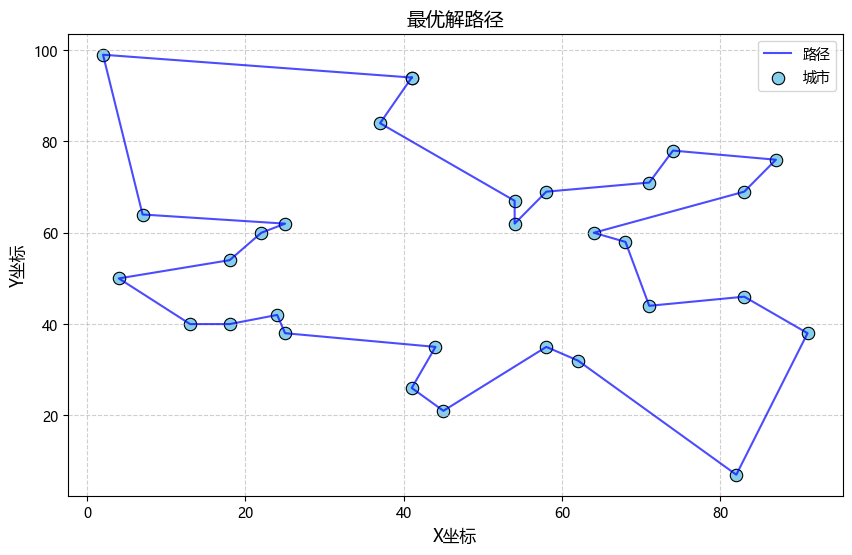

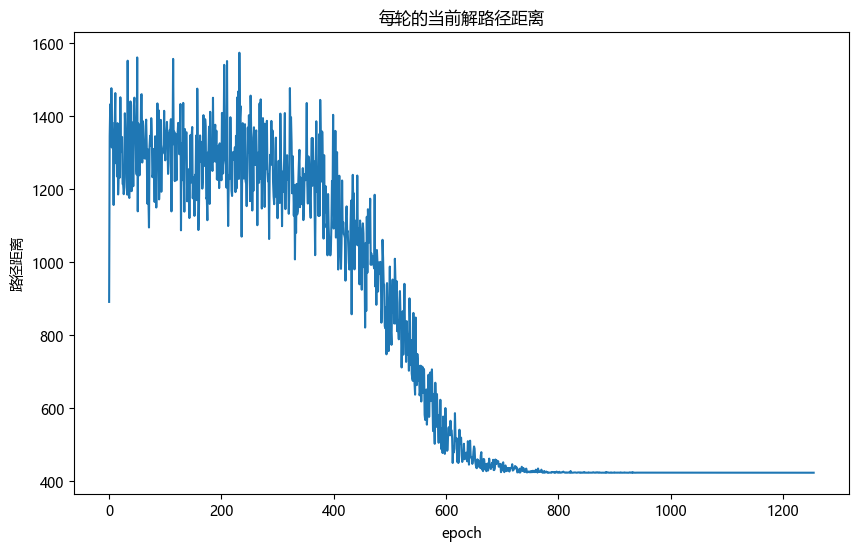

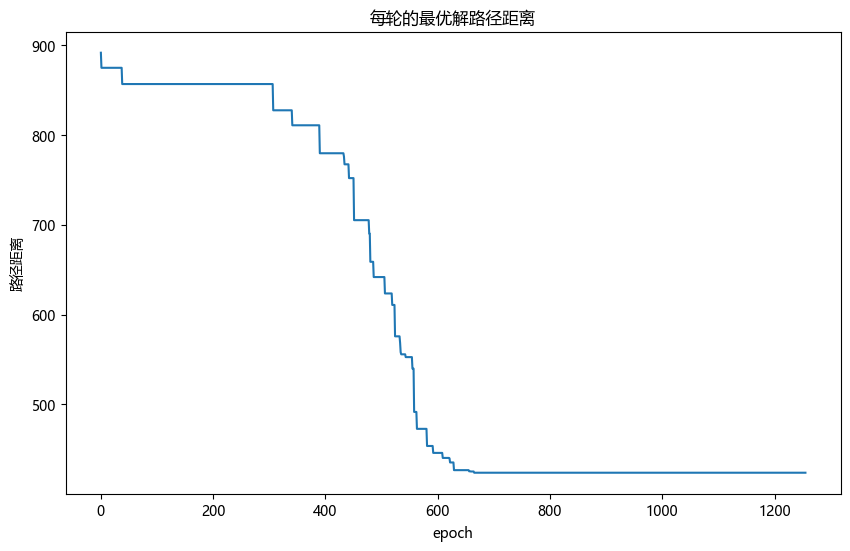

总运行时间(包括绘图): 0.68min


In [10]:
T0 = 100*30     # 初始温度
T_end = 0.01    # 最终温度
K = 0.99        # 温度衰减系数
L = 100*30      # 每轮温度，生成新可行解的数量
SA_TSP(city_coords, dist_matrix, T0, T_end, K, L, verbose=0)

从运行结果中，可以大致看出 \
对于当前解，在温度较高时，算法偏向于随机搜索，当前解的路径距离大小上下震荡；\
在温度较低时，路径距离越来越小；\
约800轮迭代后，当前解路径距离几乎不发生变化，算法趋于收敛。 \
对于记录的算法最优解，大约在650轮即达到最优，不再产生变化 \
由于模拟退火算法的随机性，在最优解停止变化之后，当前解仍然会持续变化一段时间后，才逐渐趋于收敛

优化模拟退火算法(根据上面的运行情况) \
对于当前解连续5轮的路径距离优化程度不超过0.001时，认为算法收敛，即很难再有新解替换

In [11]:
def SA_TSP_improve(city_coords, dist_matrix, T0=100, T_end=0.01, K=0.99, L=100, verbose=0):
    """ 
    模拟退火算法解决TSP问题(改进版)

    :param city_coords: 城市坐标列表
    :param dist_matrix: 城市邻接距离矩阵
    :param T0: 初始温度, 默认值100
    :param T_end: 最终温度, 默认值0.01
    :param K: 温度衰减系数, 默认值0.99
    :param L: 每轮温度，生成新可行解的数量, 默认值100
    :param verbose: 控制输出详细程度, 0只输出初始解+算法结束时的最优解及可视化+每轮路径距离变化图, 1多输出每轮当前解, 
    2多输出每50轮当前解路径可视化, 默认为0
    """
    start_time = time.time()
    
    t = T0          # 每轮的温度

    # 可以直接选0，1，2，..., 29，0作为初始路径(一个可行解)
    # 初始化最优路径、距离
    cur_path = [i for i in range(30)] + [0]                 # 初始化当前解路径
    cur_distance = cal_distance(dist_matrix, cur_path)      # 初始化当前解路径距离
    best_path = cur_path                                    # 初始化最优解路径
    best_distance = cur_distance             

    cur_distance_record = [cur_distance]                    # 记录每轮的当前解路径距离     
    best_distance_record = [best_distance]                      

    print(f"初始化路径: {cur_path}")
    print(f"初始化路径的距离: {cur_distance:.4f}")
    if verbose == 2:                                                        # 2级输出信息
        plot_tsp_path(city_coords, cur_path, title=f'初始化 当前解路径')

    epoch = 0                   # 记录外层循环次数
    count = 0                   # 记录当前解路径距离优化程度不超过0.0001的连续次数
    
    while t > T_end:            # 每轮温度不断下降
        cur_path_inner, best_path_inner = SA_TSP_sampling(L, t, dist_matrix, cur_path)   # 内层循环采样，返回循环结束后，当前解路径、最优解路径
        if cur_distance - cal_distance(dist_matrix, cur_path_inner) < 0.001:  # 内存循环当前解的距离优化程度小于0.001
            count += 1   
        else:
            count = 0

        cur_path = cur_path_inner                # 更新外层循环当前解
        cur_distance = cal_distance(dist_matrix, cur_path)

        best_distance_inner = cal_distance(dist_matrix, best_path_inner)
        if best_distance_inner < best_distance:  # 更新外层循环最优解
            best_path = best_path_inner
            best_distance = best_distance_inner
        
        cur_distance_record.append(cur_distance)
        best_distance_record.append(best_distance)

        t *= K                                   # 降温
        epoch += 1
        if verbose >= 1:                                                     # 1级输出信息
            print(f"第{epoch}轮, 温度为{t:.2f}, 当前解的路径距离: {cur_distance:4f}, 路径: {cur_path}")
        # 每隔50轮，可视化当前解的路径
        if verbose == 2 and epoch % 50 == 0:                                 # 2级输出信息
            plot_tsp_path(city_coords, cur_path, title=f'第{epoch}轮 当前解路径')

        if count > 5:                          # 认为算法已收敛，提前终止算法
            break 
        

    print(f"算法结束, 总轮数：{epoch}, 最优解路径距离: {best_distance:.4f}, 路径: {best_path}")
    plot_tsp_path(city_coords, best_path, title=f'最优解路径')

    plot_distance_record(cur_distance_record, title='每轮的当前解路径距离')
    plot_distance_record(best_distance_record, title='每轮的最优解路径距离')
    
    
    end_time = time.time()
    print(f"总运行时间(包括绘图): {(end_time-start_time)/60:.2f}min")
    

初始化路径: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 0]
初始化路径的距离: 891.8309
算法结束, 总轮数：991, 最优解路径距离: 423.7406, 路径: [0, 1, 2, 8, 17, 18, 19, 20, 9, 10, 6, 7, 13, 14, 23, 24, 25, 26, 27, 28, 15, 16, 21, 22, 29, 11, 12, 3, 4, 5, 0]


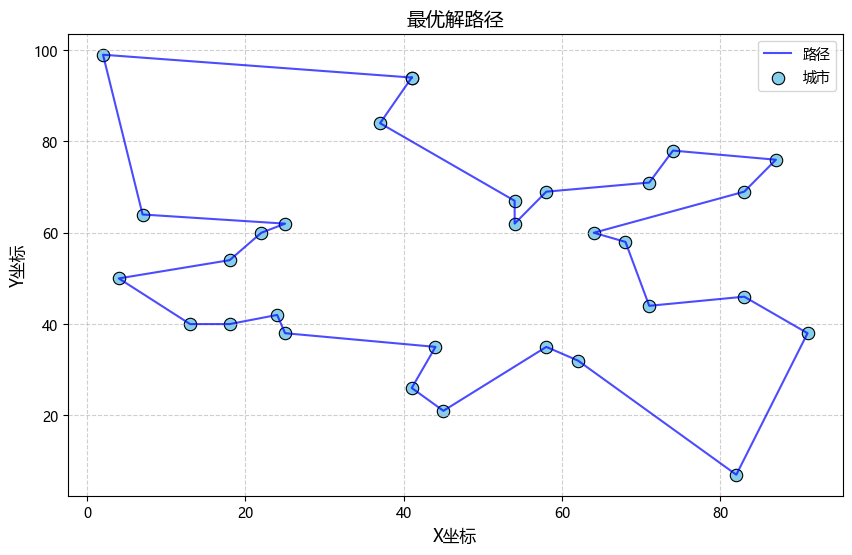

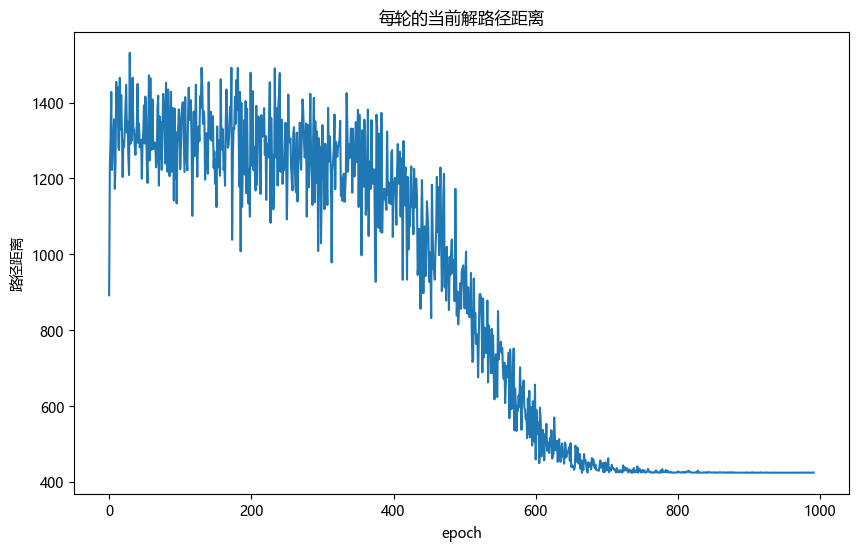

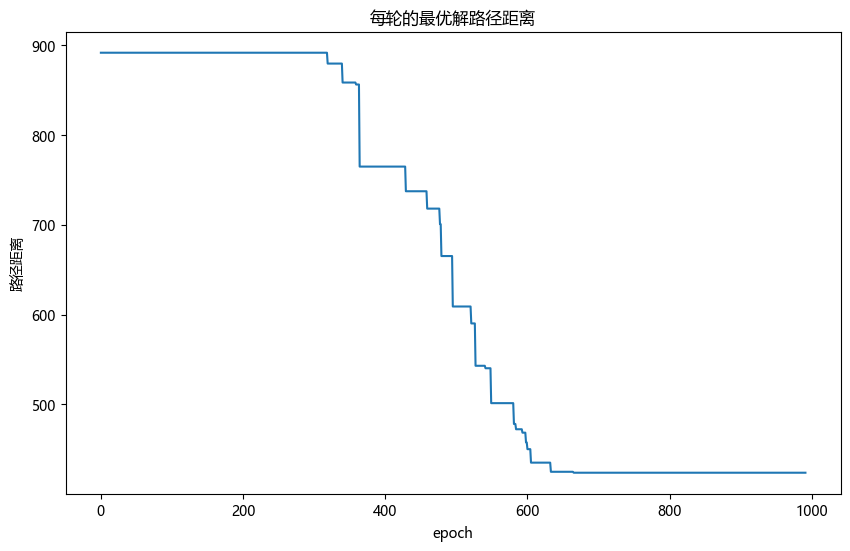

总运行时间(包括绘图): 0.55min


In [12]:
SA_TSP_improve(city_coords, dist_matrix, T0, T_end, K, L, verbose=0)